In [55]:
#  SETUP: MOUNT GOOGLE DRIVE & CREATE FOLDER STRUCTURE

from google.colab import drive
import os

# Mount Google Drive
print("🔗 Mounting Google Drive...")
drive.mount('/content/drive')

# Define your project path
BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/CodeAlpha/CodeAlpha_HandwrittenRecognition"

# Create folder structure
folders = [
    BASE_PATH,
    f"{BASE_PATH}/models",
    f"{BASE_PATH}/results",
    f"{BASE_PATH}/images"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"✅ Created: {folder}")

print(f"\n🎯 All files will save to: {BASE_PATH}")

🔗 Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Created: /content/drive/MyDrive/Colab Notebooks/CodeAlpha/CodeAlpha_HandwrittenRecognition
✅ Created: /content/drive/MyDrive/Colab Notebooks/CodeAlpha/CodeAlpha_HandwrittenRecognition/models
✅ Created: /content/drive/MyDrive/Colab Notebooks/CodeAlpha/CodeAlpha_HandwrittenRecognition/results
✅ Created: /content/drive/MyDrive/Colab Notebooks/CodeAlpha/CodeAlpha_HandwrittenRecognition/images

🎯 All files will save to: /content/drive/MyDrive/Colab Notebooks/CodeAlpha/CodeAlpha_HandwrittenRecognition


In [56]:
# WORD RECOGNITION - PRE-TRAINED CRNN (EasyOCR)


!pip install easyocr -q

import easyocr
import matplotlib.pyplot as plt
import cv2
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import json
from datetime import datetime

print("🚀 WORD RECOGNITION WITH PRE-TRAINED CRNN")
print(f"📁 Saving to: {BASE_PATH}")


# Initialize EasyOCR
print("\n📥 Loading pre-trained model...")
reader = easyocr.Reader(['en'], gpu=True, verbose=False)
print("✅ Model loaded!")

🚀 WORD RECOGNITION WITH PRE-TRAINED CRNN
📁 Saving to: /content/drive/MyDrive/Colab Notebooks/CodeAlpha/CodeAlpha_HandwrittenRecognition

📥 Loading pre-trained model...
✅ Model loaded!


In [57]:

# 📸 TEST OCR ON YOUR IMAGES

import easyocr
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os
from google.colab import drive

print("="*70)
print("🚀 TESTING OCR ON YOUR IMAGES")
print("="*70)

# Mount Google Drive
drive.mount('/content/drive')

# Your project path
BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/CodeAlpha/CodeAlpha_HandwrittenRecognition"
IMG_PATH = f"{BASE_PATH}/images"  # Where your test images are

# Initialize EasyOCR
print("\n📥 Loading OCR model...")
reader = easyocr.Reader(['en'], gpu=True, verbose=False)
print("✅ Model loaded!")

🚀 TESTING OCR ON YOUR IMAGES
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

📥 Loading OCR model...
✅ Model loaded!


In [58]:
# CHECK IF IMAGES EXIST
#

print(f"\n📁 Looking for images in: {IMG_PATH}")

# List all PNG files in img folder
if os.path.exists(IMG_PATH):
    test_images = [f for f in os.listdir(IMG_PATH) if f.endswith('.png')]
    test_images.sort()  # Sort: test1.png, test2.png, test3.png, test4.png

    print(f"\n✅ Found {len(test_images)} images:")
    for img in test_images:
        print(f"   • {img}")
else:
    print(f"❌ Folder not found: {IMG_PATH}")
    print("💡 Creating folder... Please upload your images there.")
    os.makedirs(IMG_PATH, exist_ok=True)
    test_images = []


📁 Looking for images in: /content/drive/MyDrive/Colab Notebooks/CodeAlpha/CodeAlpha_HandwrittenRecognition/images

✅ Found 9 images:
   • test1.png
   • test2.png
   • test3.png
   • test4.png
   • test_ai.png
   • test_crnn.png
   • test_hello.png
   • test_test.png
   • test_world.png


In [59]:

# OCR VISUALIZATION FUNCTION

def test_ocr_on_image(image_path):
    """
    Test OCR on single image with nice visualization
    """
    # Load image
    img = cv2.imread(image_path)
    if img is None:
        print(f"❌ Could not load: {image_path}")
        return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Get OCR results
    results = reader.readtext(img)

    # Create visualization
    plt.figure(figsize=(16, 6))

    # Original image
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"Original: {os.path.basename(image_path)}", fontsize=12, fontweight='bold')
    plt.axis('off')

    # Annotated image
    annotated = img.copy()
    for (bbox, text, confidence) in results:
        # Draw bounding box
        pts = np.array(bbox, dtype=np.int32).reshape((-1, 1, 2))
        cv2.polylines(annotated, [pts], isClosed=True, color=(0, 255, 0), thickness=3)

        # Add text with background
        (label_w, label_h), _ = cv2.getTextSize(f"{text} {confidence*100:.0f}%",
                                                  cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
        cv2.rectangle(annotated, (pts[0][0][0], pts[0][0][1] - 30),
                     (pts[0][0][0] + label_w, pts[0][0][1]), (0, 255, 0), -1)
        cv2.putText(annotated, f"{text} {confidence*100:.0f}%",
                   (pts[0][0][0], pts[0][0][1] - 8),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)

    plt.subplot(1, 2, 2)
    plt.imshow(annotated)
    plt.title("OCR Detection Results", fontsize=12, fontweight='bold')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    # Print detailed results
    print(f"\n📝 Results for {os.path.basename(image_path)}:")
    print("-" * 60)
    if results:
        for i, (bbox, text, confidence) in enumerate(results, 1):
            print(f"   {i}. Text: '{text}'")
            print(f"      Confidence: {confidence*100:.2f}%")
            print(f"      Position: {bbox[0]}")
            print()
    else:
        print("   ❌ No text detected")
    print("-" * 60)

    return results


🔮 TESTING ON 9 IMAGES

📷 Processing: test1.png


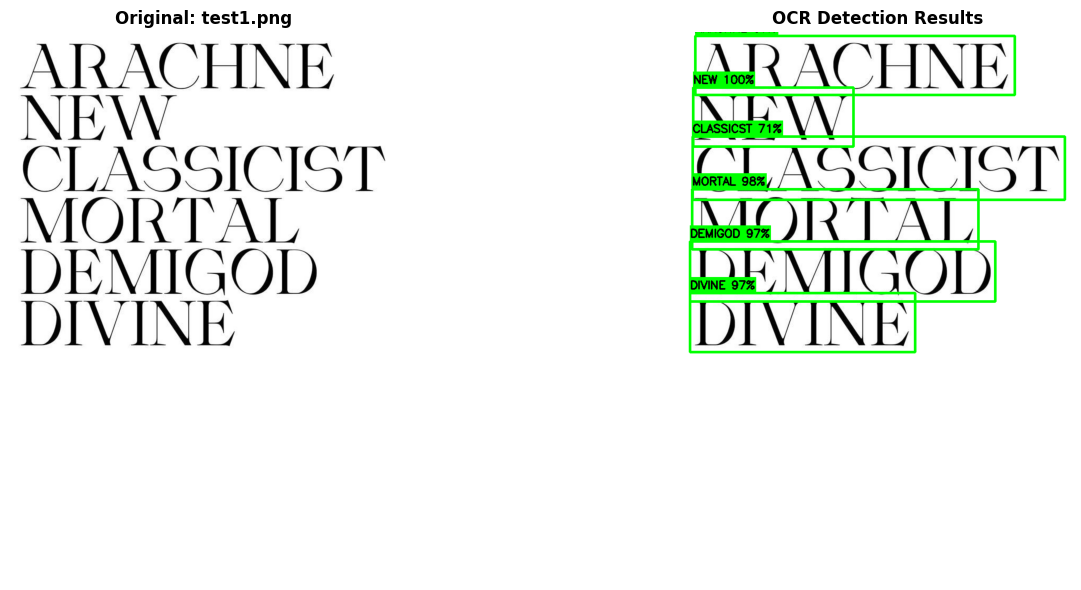


📝 Results for test1.png:
------------------------------------------------------------
   1. Text: 'ARACHNE'
      Confidence: 87.34%
      Position: [np.int32(21), np.int32(7)]

   2. Text: 'NEW'
      Confidence: 99.99%
      Position: [np.int32(17), np.int32(105)]

   3. Text: 'CLASSICST'
      Confidence: 70.86%
      Position: [np.int32(16), np.int32(198)]

   4. Text: 'MORTAL'
      Confidence: 98.19%
      Position: [np.int32(15), np.int32(298)]

   5. Text: 'DEMIGOD'
      Confidence: 97.04%
      Position: [np.int32(11), np.int32(397)]

   6. Text: 'DIVINE'
      Confidence: 97.02%
      Position: [np.int32(11), np.int32(495)]

------------------------------------------------------------

📷 Processing: test2.png


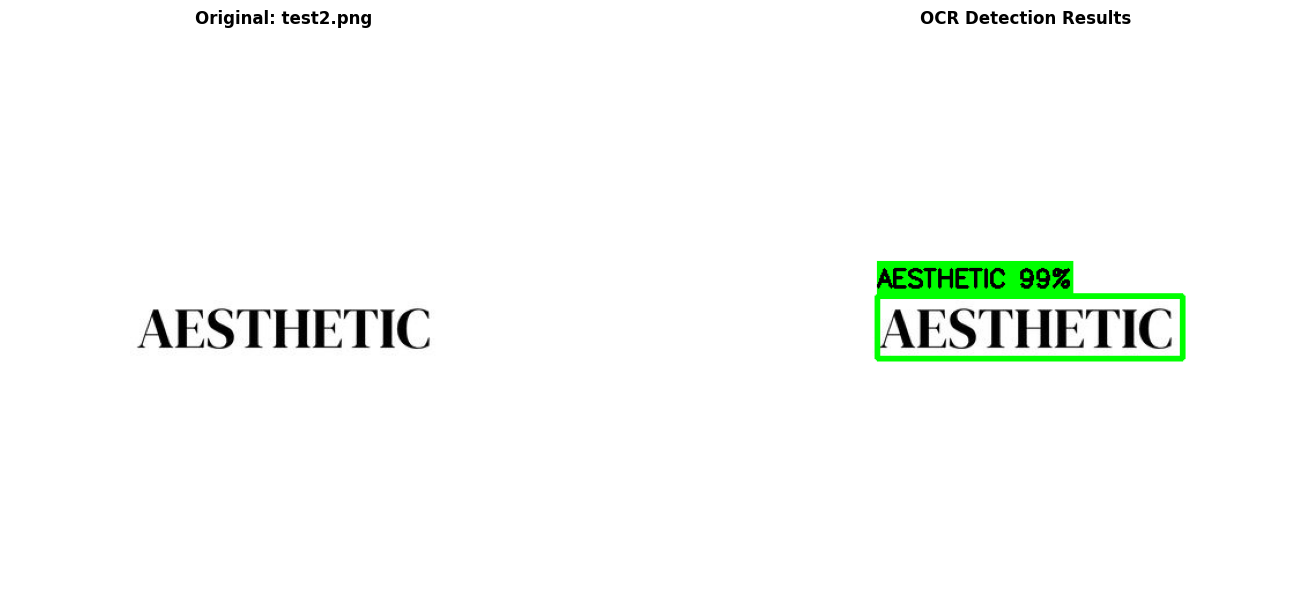


📝 Results for test2.png:
------------------------------------------------------------
   1. Text: 'AESTHETIC'
      Confidence: 99.23%
      Position: [np.int32(108), np.int32(228)]

------------------------------------------------------------

📷 Processing: test3.png


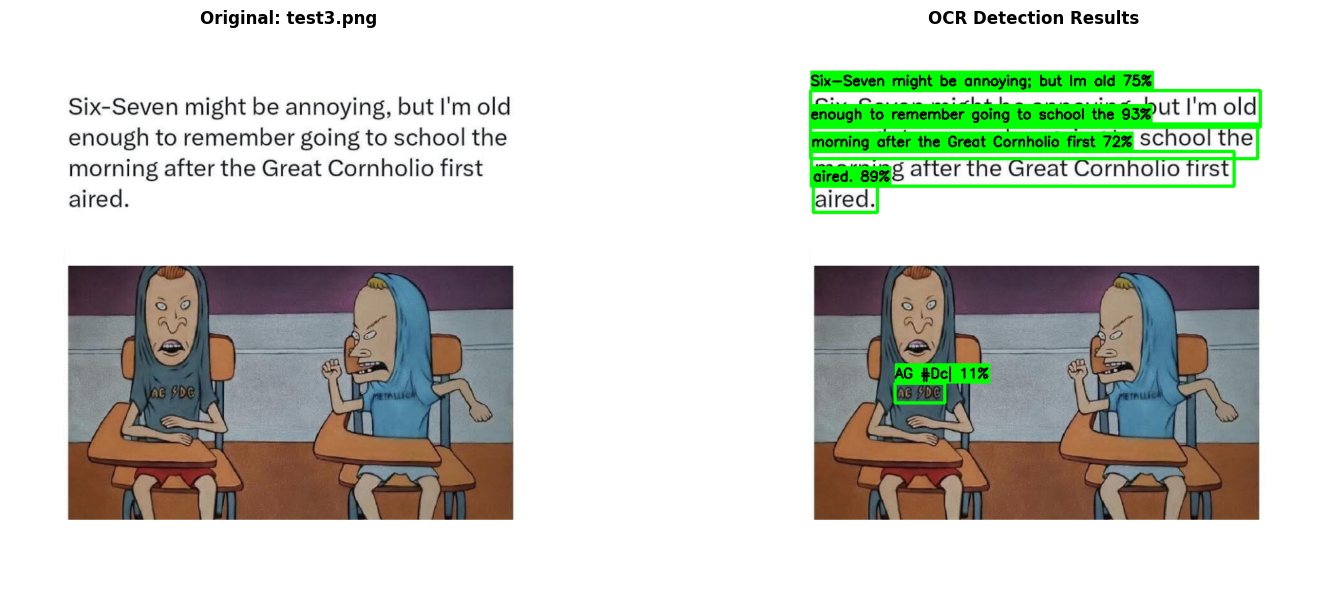


📝 Results for test3.png:
------------------------------------------------------------
   1. Text: 'Six-Seven might be annoying; but Im old'
      Confidence: 75.41%
      Position: [np.int32(83), np.int32(89)]

   2. Text: 'enough to remember going to school the'
      Confidence: 92.78%
      Position: [np.int32(83), np.int32(140)]

   3. Text: 'morning after the Great Cornholio first'
      Confidence: 72.46%
      Position: [np.int32(84), np.int32(182)]

   4. Text: 'aired.'
      Confidence: 89.15%
      Position: [np.int32(87), np.int32(235)]

   5. Text: 'AG #Dc|'
      Confidence: 11.35%
      Position: [np.int32(212), np.int32(536)]

------------------------------------------------------------

📷 Processing: test4.png


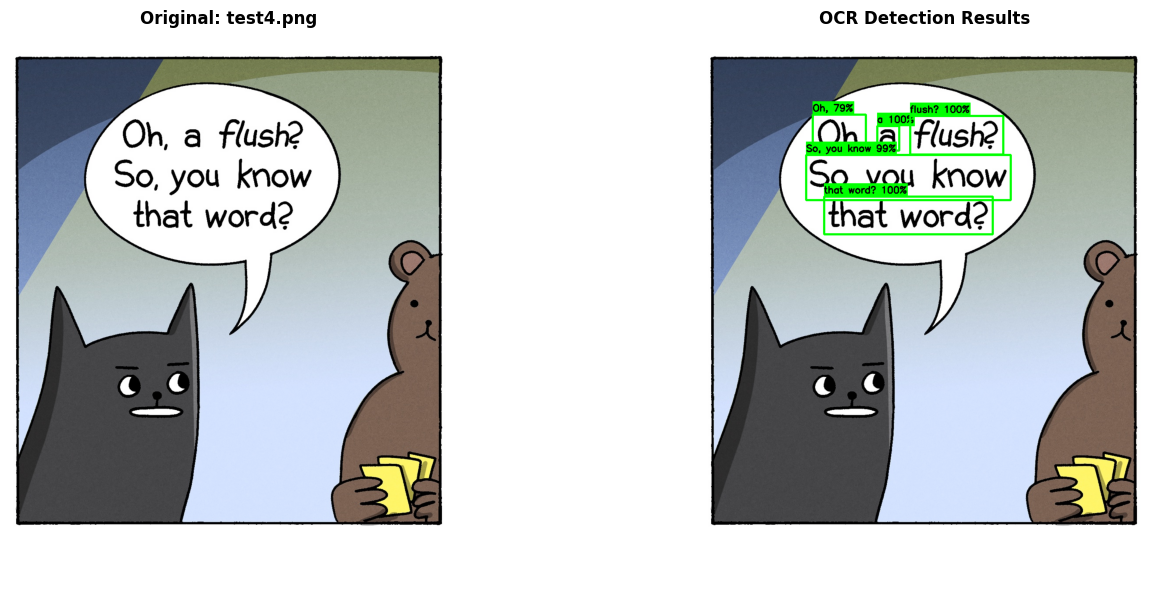


📝 Results for test4.png:
------------------------------------------------------------
   1. Text: 'Oh,'
      Confidence: 79.17%
      Position: [np.int32(245), np.int32(188)]

   2. Text: 'a'
      Confidence: 99.96%
      Position: [np.int32(392), np.int32(214)]

   3. Text: 'flush?'
      Confidence: 99.72%
      Position: [np.int32(467), np.int32(191)]

   4. Text: 'So, you know'
      Confidence: 99.19%
      Position: [np.int32(230), np.int32(280)]

   5. Text: 'that word?'
      Confidence: 99.89%
      Position: [np.int32(271), np.int32(375)]

------------------------------------------------------------

📷 Processing: test_ai.png


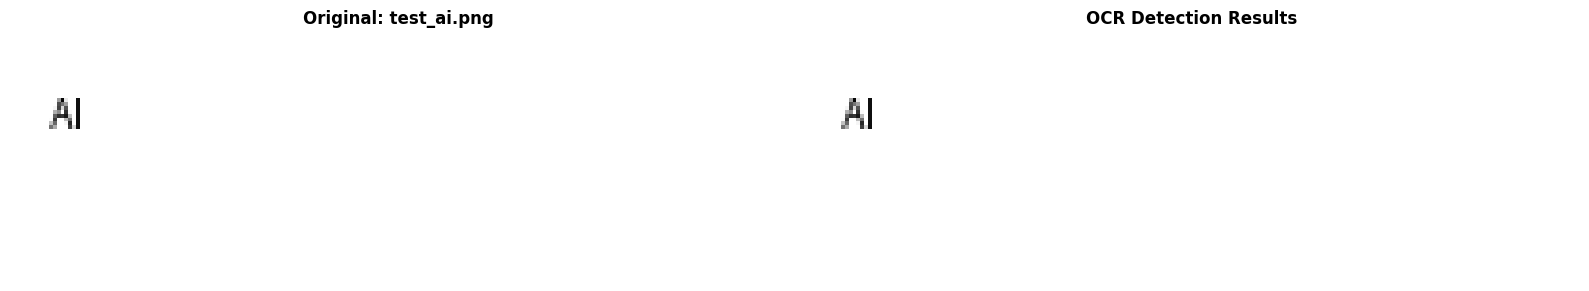


📝 Results for test_ai.png:
------------------------------------------------------------
   ❌ No text detected
------------------------------------------------------------

📷 Processing: test_crnn.png


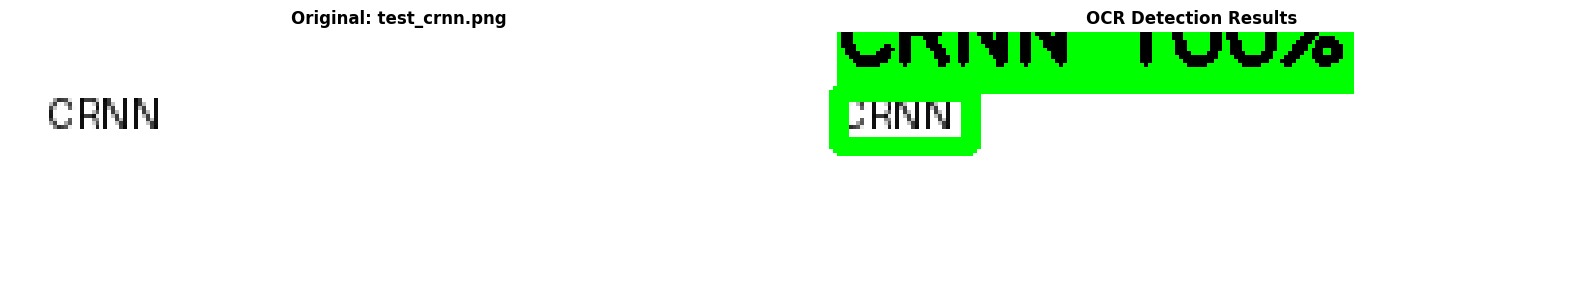


📝 Results for test_crnn.png:
------------------------------------------------------------
   1. Text: 'CRNN'
      Confidence: 99.91%
      Position: [np.int32(9), np.int32(15)]

------------------------------------------------------------

📷 Processing: test_hello.png


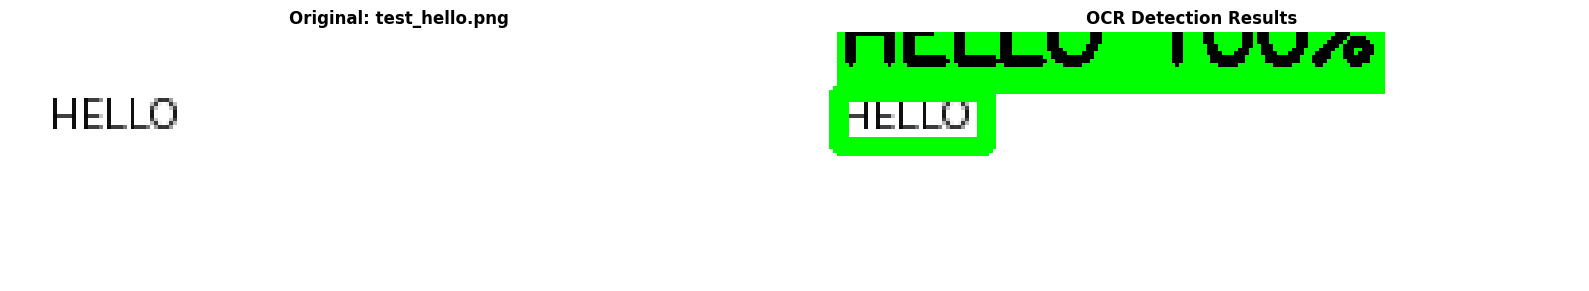


📝 Results for test_hello.png:
------------------------------------------------------------
   1. Text: 'HELLO'
      Confidence: 99.91%
      Position: [np.int32(9), np.int32(15)]

------------------------------------------------------------

📷 Processing: test_test.png


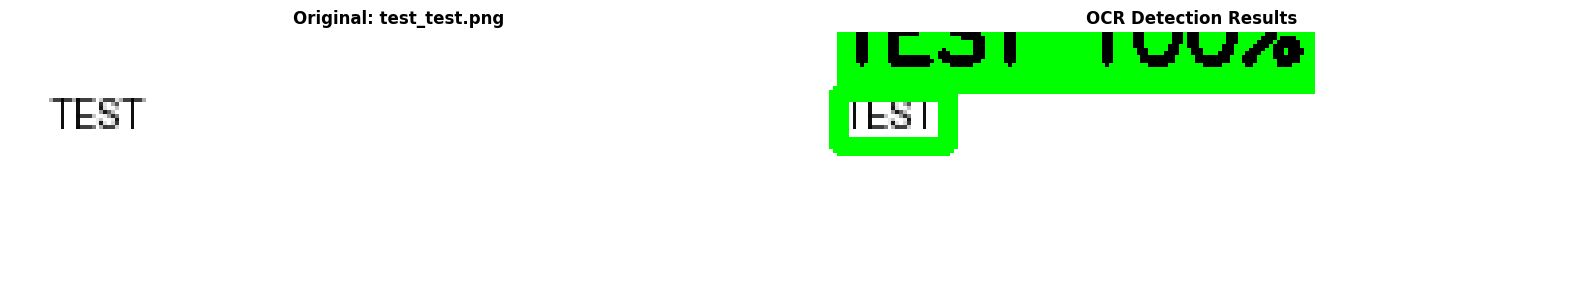


📝 Results for test_test.png:
------------------------------------------------------------
   1. Text: 'TEST'
      Confidence: 99.99%
      Position: [np.int32(9), np.int32(15)]

------------------------------------------------------------

📷 Processing: test_world.png


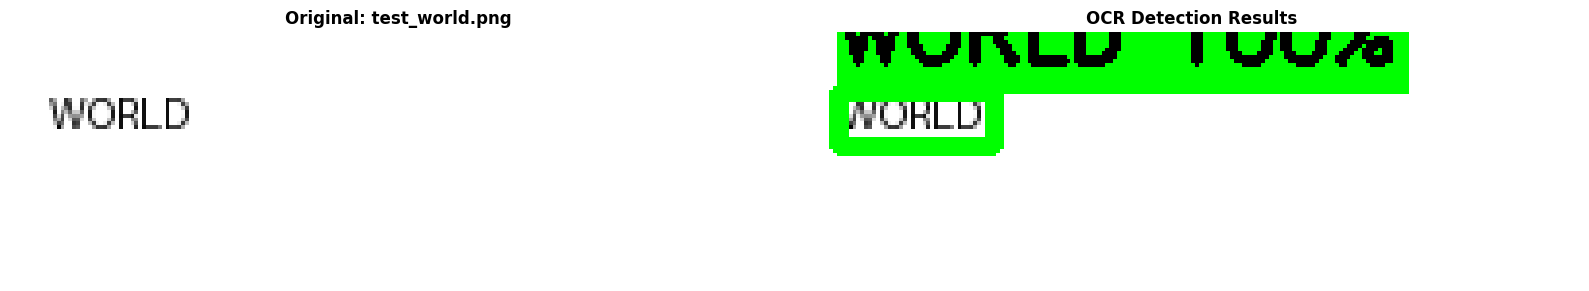


📝 Results for test_world.png:
------------------------------------------------------------
   1. Text: 'WORLD'
      Confidence: 99.95%
      Position: [np.int32(9), np.int32(15)]

------------------------------------------------------------


In [60]:

# TEST ON ALL IMAGES

if test_images:
    print(f"\n{'='*70}")
    print(f"🔮 TESTING ON {len(test_images)} IMAGES")
    print('='*70)

    all_results = {}

    for img_name in test_images:
        img_path = os.path.join(IMG_PATH, img_name)
        print(f"\n📷 Processing: {img_name}")

        results = test_ocr_on_image(img_path)

        # Store results
        all_results[img_name] = [
            {'text': text, 'confidence': round(conf*100, 2)}
            for (_, text, conf) in results
        ] if results else []


In [61]:
# =============================================================================
# 💾 SAVE RESULTS TO DRIVE
# =============================================================================

print("\n💾 Saving results to Drive...")

# Create timestamp for unique filename
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
report_path = f"{BASE_PATH}/results/ocr_test_results_{timestamp}.json"

# Save JSON report
with open(report_path, 'w') as f:
    json.dump(all_results, f, indent=2)
print(f"✅ Saved: {report_path}")

# Print summary
print(f"\n{'='*70}")
print("📊 SUMMARY")
print('='*70)

for img_name, results in all_results.items():
    texts = [r['text'] for r in results]
    print(f"📄 {img_name}: {', '.join(texts) if texts else 'No text detected'}")

# Calculate statistics
total_images = len(all_results)
successful = sum(1 for r in all_results.values() if r)
total_words = sum(len(r) for r in all_results.values())
avg_confidence = np.mean([r['confidence'] for results in all_results.values()
                          for r in results]) if total_words > 0 else 0

print(f"\n📈 Overall Statistics:")
print(f"   • Total Images: {total_images}")
print(f"   • Successfully Processed: {successful} ({successful/total_images*100:.1f}%)")
print(f"   • Total Words Detected: {total_words}")
print(f"   • Average Confidence: {avg_confidence:.2f}%")
print('='*70)

print(f"\n📁 All results saved to: {BASE_PATH}/results/")
print("\n" + "="*70)
print("✅ TESTING COMPLETE!")
print("="*70)


💾 Saving results to Drive...
✅ Saved: /content/drive/MyDrive/Colab Notebooks/CodeAlpha/CodeAlpha_HandwrittenRecognition/results/ocr_test_results_20260323_231732.json

📊 SUMMARY
📄 test1.png: ARACHNE, NEW, CLASSICST, MORTAL, DEMIGOD, DIVINE
📄 test2.png: AESTHETIC
📄 test3.png: Six-Seven might be annoying; but Im old, enough to remember going to school the, morning after the Great Cornholio first, aired., AG #Dc|
📄 test4.png: Oh,, a, flush?, So, you know, that word?
📄 test_ai.png: No text detected
📄 test_crnn.png: CRNN
📄 test_hello.png: HELLO
📄 test_test.png: TEST
📄 test_world.png: WORLD

📈 Overall Statistics:
   • Total Images: 9
   • Successfully Processed: 8 (88.9%)
   • Total Words Detected: 21
   • Average Confidence: 88.98%

📁 All results saved to: /content/drive/MyDrive/Colab Notebooks/CodeAlpha/CodeAlpha_HandwrittenRecognition/results/

✅ TESTING COMPLETE!
